# 03 – Narrative Volatility Index (NVI)

## 1. Introduction

This notebook constructs the **Narrative Volatility Index (NVI)**, a country-level indicator designed to measure instability in geopolitical narratives over time.

The index is based on GDELT event data and focuses on temporal variation rather than only the average level of events or sentiment. Instead of measuring how positive, negative, cooperative, or conflictual a country appears on average, the NVI measures how unstable these narrative signals are over a rolling time window.

The main steps in this notebook are:

- aggregating cleaned GDELT event data at the country-month level,
- computing structural entropy from QuadClass event distributions,
- calculating rolling volatility for tone, Goldstein score, and entropy,
- constructing the final NVI as a composite z-score index,
- classifying countries into narrative regimes,
- testing the robustness of regime labels using alternative thresholding methods,
- comparing percentile-based regimes with KMeans clustering,
- interpreting selected country-level and regional patterns.

## 2. Conceptual Framework

The NVI is not a clustering algorithm. It is a continuous composite index. The regime labels are added later only to make the index easier to interpret.

In this project, narrative instability is represented through three dimensions:

1. **Tone volatility:** instability in the emotional tone of media coverage.
2. **Goldstein volatility:** instability in cooperation-conflict signals.
3. **Entropy volatility:** instability in the diversity of broad event classes.

These components are standardized and combined into a single index.

## 3. Data Source

This notebook uses the cleaned event-level table created in the previous data cleaning notebook. The cleaned table is named `exports_main_clean` and contains GDELT records filtered to the intended study period.

The table includes the variables required for country-month aggregation and NVI construction, including event dates, action geography, QuadClass, GoldsteinScale, AvgTone, and media coverage variables.

In [1]:
import duckdb

# Connect to the DuckDB database
con = duckdb.connect("../data/intermediate/gdelt_main.db")

# Display all tables in the database
con.execute("SHOW TABLES").fetchdf()

,name
0,country_filter
1,exports_main
2,exports_main_clean
3,narrative_country_12month
4,narrative_country_clean
5,narrative_country_full
6,narrative_country_month
7,narrative_nvi
8,narrative_volatility
9,narrative_volatility_2025


In [2]:
# Preview the cleaned event table
con.execute("""
SELECT *
FROM exports_main_clean
LIMIT 10
""").fetchdf()

,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,...,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1218366364,20250101,202501,2025,2025.0027,None,None,Unknown,None,AGR,...,0,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,20250101000000,https://www.tribuneindia.com/news/ludhiana/int...
1,1218366365,20250101,202501,2025,2025.0027,None,None,Unknown,None,AGR,...,1,Malta,MT,MT,NaN,35.916667,14.433333,MT,20250101000000,https://www.slashfilm.com/1748346/oscar-winnin...
2,1218366366,20250101,202501,2025,2025.0027,None,None,Unknown,None,AUS,...,4,"Brisbane, Queensland, Australia",AS,AS04,154654,-27.500000,153.017,-1561728,20250101000000,https://www.today.com/life/holidays/new-year-t...
3,1218366367,20250101,202501,2025,2025.0027,None,None,Unknown,None,AUT,...,4,"Vienna, Wien, Austria",AU,AU09,5672,48.200000,16.3667,-1995499,20250101000000,https://abc17news.com/news/crime/2024/12/31/ma...
4,1218366368,20250101,202501,2025,2025.0027,None,None,Unknown,None,BEL,...,0,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,20250101000000,https://kitchener.ctvnews.ca/driver-charged-af...
5,1218366369,20250101,202501,2025,2025.0027,None,None,Unknown,None,BUS,...,2,"Pennsylvania, United States",US,USPA,NaN,40.577300,-77.264,PA,20250101000000,https://fox56.com/news/local/pennsylvania-town...
6,1218366370,20250101,202501,2025,2025.0027,None,None,Unknown,None,BUS,...,0,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,20250101000000,https://www.hudsonstarobserver.com/news/belove...
7,1218366371,20250101,202501,2025,2025.0027,None,None,Unknown,None,BUS,...,0,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,20250101000000,https://upnorthlive.com/news/local/mecosta-cou...
8,1218366372,20250101,202501,2025,2025.0027,None,None,Unknown,None,CAN,...,0,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,20250101000000,https://www.fox17online.com/news/local-news/la...
9,1218366373,20250101,202501,2025,2025.0027,None,None,Unknown,None,CAN,...,0,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,20250101000000,https://www.fox17online.com/news/local-news/la...


## 4. Country-Month Aggregation

The raw GDELT data is event-level. Since the NVI is designed to measure temporal narrative instability by country, the data is aggregated to the country-month level.

The aggregation uses `ActionGeo_CountryCode` as the country identifier because it represents the geographic location where the event action occurred. Monthly averages are computed for narrative indicators such as `AvgTone` and `GoldsteinScale`, while event counts are used to represent the volume of events.

### 4.1 Create Country–Month Aggregation

In [3]:
con.execute("""
CREATE OR REPLACE TABLE narrative_country_month AS
SELECT
    DATE_TRUNC(
        'month',
        STRPTIME(CAST(Day AS VARCHAR), '%Y%m%d')
    ) AS year_month,

    Actor1CountryCode AS country,

    COUNT(*) AS event_count,

    AVG(AvgTone) AS tone_mean,
    STDDEV(AvgTone) AS tone_std,

    AVG(GoldsteinScale) AS goldstein_mean,
    STDDEV(GoldsteinScale) AS goldstein_std,

    SUM(CASE WHEN QuadClass = 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad1_ratio,
    SUM(CASE WHEN QuadClass = 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad2_ratio,
    SUM(CASE WHEN QuadClass = 3 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad3_ratio,
    SUM(CASE WHEN QuadClass = 4 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad4_ratio

FROM exports_main_clean
WHERE Actor1CountryCode IS NOT NULL
AND Actor1CountryCode != 'Unknown'

GROUP BY 1,2;
""")

### 4.2 Inspect Aggregated Data

To verify that the aggregation was performed correctly,
we preview the first rows of the `narrative_country_month` table.

In [5]:
con.execute("""
SELECT *
FROM narrative_country_month
ORDER BY country, year_month
LIMIT 20
""").fetchdf()

,year_month,country,event_count,tone_mean,tone_std,goldstein_mean,goldstein_std,quad1_ratio,quad2_ratio,quad3_ratio,quad4_ratio
0,2025-01-01,ABW,88,1.808674,6.035664,0.463636,4.119904,0.693182,0.056818,0.068182,0.181818
1,2025-02-01,ABW,71,1.983232,2.416151,1.876056,2.862739,0.845070,0.056338,0.056338,0.042254
2,2025-03-01,ABW,122,-0.556585,4.042924,0.143443,4.155391,0.680328,0.065574,0.114754,0.139344
3,2025-04-01,ABW,80,-2.409526,5.844908,0.937500,3.590824,0.775000,0.012500,0.100000,0.112500
4,2025-05-01,ABW,109,-0.970551,4.835004,0.488991,4.128320,0.614679,0.082569,0.192661,0.110092
5,2025-06-01,ABW,37,-0.292545,5.834425,1.500000,2.493213,0.810811,0.000000,0.162162,0.027027
6,2025-07-01,ABW,104,1.022257,4.098140,1.900962,3.411815,0.759615,0.105769,0.096154,0.038462
7,2025-08-01,ABW,58,0.895956,4.122117,2.074138,2.758245,0.793103,0.137931,0.051724,0.017241
8,2025-09-01,ABW,79,0.717426,3.832834,1.834177,2.249666,0.873418,0.037975,0.075949,0.012658
9,2025-10-01,ABW,94,-0.201395,4.937955,1.272340,3.273957,0.819149,0.053191,0.053191,0.074468


### 4.3 Verify Dataset Dates

We confirm that the dataset contains only the intended months.

In [6]:
con.execute("""
SELECT DISTINCT year_month
FROM narrative_country_month
ORDER BY year_month
""").fetchdf()

,year_month
0,2025-01-01
1,2025-02-01
2,2025-03-01
3,2025-04-01
4,2025-05-01
5,2025-06-01
6,2025-07-01
7,2025-08-01
8,2025-09-01
9,2025-10-01


## 5. Structural Entropy

To capture narrative diversity, **Shannon entropy** is computed over the
QuadClass distribution.

     H = - Σ (p_i * log(p_i))

where \(p_i\) is the proportion of events in QuadClass \(i\) for a given
country–month.

**Interpretation**

- Low entropy → narrative concentrated in a single event type
- High entropy → heterogeneous event structure

Entropy serves as a proxy for **structural narrative fragmentation**
within national media narratives.

Entropy is not used directly as the final indicator. Instead, the rolling volatility of entropy is used to measure instability in the structure of event types over time.

### 5.1 Add Entropy Column

In [7]:
# Add column for QuadClass entropy
con.execute("""
ALTER TABLE narrative_country_month
ADD COLUMN quad_entropy DOUBLE;
""")

### 5.2 Compute Shannon Entropy

In [8]:
# Compute Shannon entropy for each row
con.execute("""
UPDATE narrative_country_month
SET quad_entropy =
- (
    COALESCE(quad1_ratio * LN(NULLIF(quad1_ratio,0)), 0) +
    COALESCE(quad2_ratio * LN(NULLIF(quad2_ratio,0)), 0) +
    COALESCE(quad3_ratio * LN(NULLIF(quad3_ratio,0)), 0) +
    COALESCE(quad4_ratio * LN(NULLIF(quad4_ratio,0)), 0)
);
""")

### 5.3 Inspect Entropy Values

We preview the country–month observations with the highest entropy
values to examine highly heterogeneous narrative structures.

In [9]:
# Preview top 10 rows by entropy
con.execute("""
SELECT country, year_month,
       quad1_ratio, quad2_ratio, quad3_ratio, quad4_ratio,
       quad_entropy
FROM narrative_country_month
ORDER BY quad_entropy DESC
LIMIT 10
""").fetchdf()

,country,year_month,quad1_ratio,quad2_ratio,quad3_ratio,quad4_ratio,quad_entropy
0,HND,2025-12-01,0.386540,0.273224,0.153005,0.187230,1.322835
1,MLI,2025-01-01,0.454778,0.159556,0.198805,0.186860,1.285778
2,NER,2026-01-01,0.417989,0.106576,0.222222,0.253212,1.285258
3,MLI,2025-08-01,0.417797,0.122881,0.172881,0.286441,1.283809
4,SWZ,2025-06-01,0.411765,0.117647,0.294118,0.176471,1.283173
5,VEN,2025-07-01,0.450176,0.200539,0.125751,0.223534,1.277144
6,BDI,2025-03-01,0.466495,0.164948,0.190722,0.177835,1.276081
7,PRK,2025-03-01,0.467258,0.167300,0.171525,0.193916,1.275141
8,SDN,2025-05-01,0.426553,0.115713,0.174178,0.283557,1.274768
9,SLV,2025-07-01,0.449172,0.161336,0.133352,0.256139,1.271358


## 6. Exploratory Data Analysis

Before calculating rolling volatility and constructing the NVI, the country-month dataset is explored to understand the distribution of the main narrative indicators.

This step helps identify skewness, outliers, and general patterns in the aggregated data. The analysis focuses on event counts, average tone, average Goldstein score, and QuadClass entropy.

In [10]:
eda_df = con.execute("""
SELECT *
FROM narrative_country_month
""").fetchdf()

eda_df.head()

,year_month,country,event_count,tone_mean,tone_std,goldstein_mean,goldstein_std,quad1_ratio,quad2_ratio,quad3_ratio,quad4_ratio,quad_entropy
0,2025-01-01,ZWE,5466,-2.288796,4.860481,0.605873,4.269729,0.611050,0.127150,0.138310,0.123491,1.095125
1,2025-01-01,BEN,852,-1.214646,4.924576,0.800704,4.547992,0.699531,0.055164,0.146714,0.098592,0.919807
2,2025-01-01,CAN,59026,-1.119407,3.381648,0.967199,4.414220,0.610375,0.155609,0.123437,0.110578,1.092558
3,2025-01-01,CHE,11720,-0.421412,3.957527,1.582978,3.847755,0.740102,0.099232,0.084812,0.075853,0.856882
4,2025-01-01,DEU,26636,-1.806426,3.700628,0.914244,4.502380,0.642889,0.115858,0.127759,0.113493,1.043578


In [12]:
eda_cols = [
    "event_count",
    "tone_mean",
    "goldstein_mean",
    "quad_entropy"
]

eda_df[eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
event_count,3253.0,8776.741469,42077.378859,1.000000,442.000000,1464.000000,5100.000000,702105.000000
tone_mean,3253.0,-0.976496,1.735900,-14.112903,-2.045645,-0.972541,0.121353,6.728232
goldstein_mean,3253.0,1.210140,0.998924,-7.200000,0.647844,1.218338,1.806909,6.739130
quad_entropy,3253.0,0.911865,0.217109,-0.000000,0.814131,0.957138,1.054909,1.322835


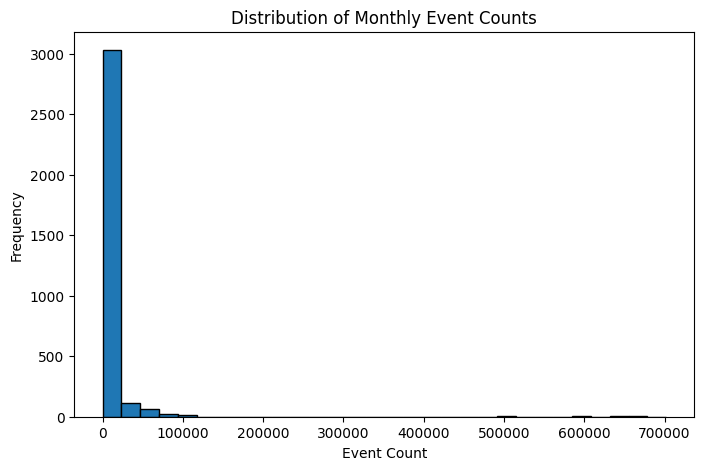

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(eda_df["event_count"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Monthly Event Counts")
plt.xlabel("Event Count")
plt.ylabel("Frequency")
plt.show()

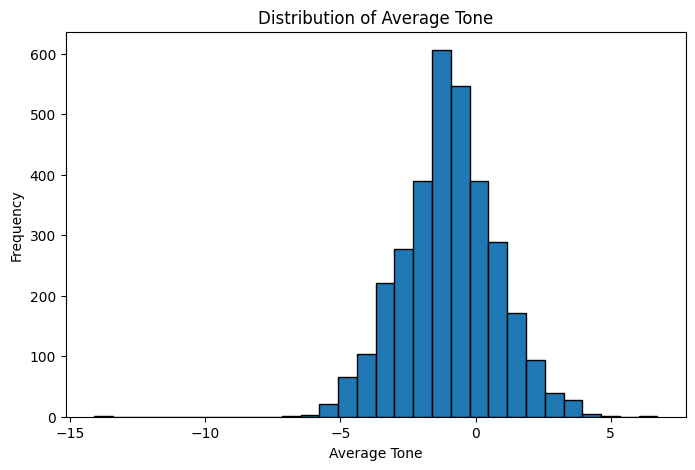

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(eda_df["tone_mean"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Average Tone")
plt.xlabel("Average Tone")
plt.ylabel("Frequency")
plt.show()

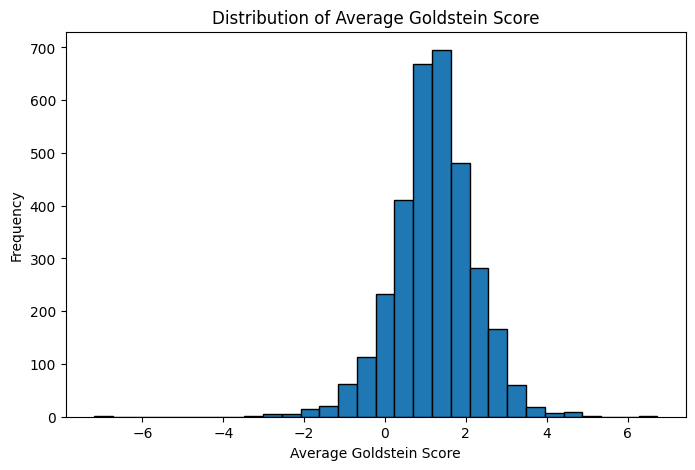

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(eda_df["goldstein_mean"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Average Goldstein Score")
plt.xlabel("Average Goldstein Score")
plt.ylabel("Frequency")
plt.show()

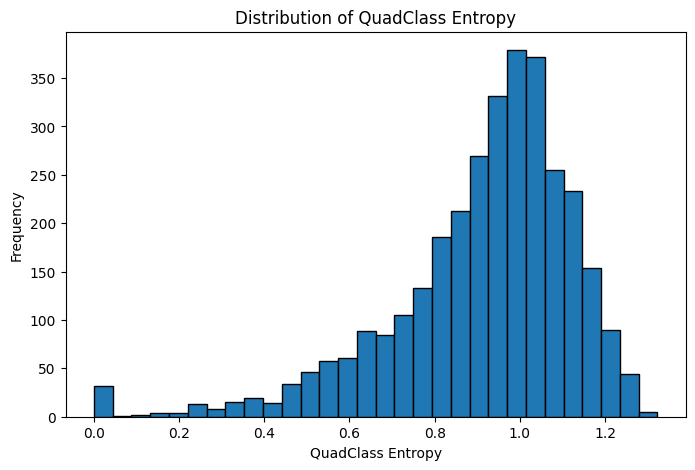

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(eda_df["quad_entropy"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of QuadClass Entropy")
plt.xlabel("QuadClass Entropy")
plt.ylabel("Frequency")
plt.show()

In [20]:
eda_df[eda_cols].corr()

,event_count,tone_mean,goldstein_mean,quad_entropy
event_count,1.000000,-0.110136,-0.121006,0.144435
tone_mean,-0.110136,1.000000,0.724931,-0.681907
goldstein_mean,-0.121006,0.724931,1.000000,-0.686749
quad_entropy,0.144435,-0.681907,-0.686749,1.000000


The correlation matrix shows that `tone_mean` and `goldstein_mean` are positively correlated. This suggests that months with more positive media tone also tend to have more cooperative Goldstein scores.

In contrast, `quad_entropy` is negatively correlated with both `tone_mean` and `goldstein_mean`. This indicates that months with more diverse event-class structures tend to be associated with lower average tone and lower cooperation-oriented Goldstein scores.

The correlations between `event_count` and the other indicators are relatively weak. This suggests that event volume captures a different aspect of the data than tone, Goldstein score, or event-class entropy. Therefore, the NVI focuses on volatility in narrative indicators rather than simply using event count as a proxy for instability.

The exploratory analysis shows how the main country-month indicators are distributed before volatility is computed. Event counts are expected to be skewed because some countries receive much more media coverage than others. Tone, Goldstein score, and entropy provide different dimensions of the narrative structure and are later transformed into rolling volatility measures.

## 7. Volatility

Narrative volatility is estimated using a **rolling twelve-month window**.

For each country, we compute the rolling standard deviation of:

- Mean event tone (`tone_mean`)
- Mean Goldstein score (`goldstein_mean`)
- Structural entropy (`quad_entropy`)

The rolling window includes the **current month and the eleven preceding months**.

Volatility captures **dispersion in narrative signals rather than their absolute level**.

For each country, volatility at time `t` summarizes how much the corresponding indicator fluctuated over the previous 12 months.

This makes the analysis time-series based, but the objective is not forecasting. The goal is to measure historical narrative instability through rolling temporal variation.

### 7.1 Compute Rolling Volatility

In [23]:
# Compute 12-month rolling volatility for tone, goldstein, and entropy
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility AS
SELECT
    country,
    year_month,

    STDDEV(tone_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS tone_vol,

    STDDEV(goldstein_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS goldstein_vol,

    STDDEV(quad_entropy) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS entropy_vol

FROM narrative_country_month;
""")

### 7.2 Inspect Volatility Estimates

We preview the computed volatility values for each country–month
to ensure that the rolling window calculation behaves as expected.

In [24]:
con.execute("""
SELECT *
FROM narrative_volatility
ORDER BY country, year_month
LIMIT 12
""").fetchdf()

,country,year_month,tone_vol,goldstein_vol,entropy_vol
0,ABW,2025-01-01,NaN,NaN,NaN
1,ABW,2025-02-01,0.123431,0.998732,0.219195
2,ABW,2025-03-01,1.418661,0.921901,0.196330
3,ABW,2025-04-01,2.093611,0.754728,0.167371
4,ABW,2025-05-01,1.887981,0.673815,0.187147
5,ABW,2025-06-01,1.692087,0.670194,0.205230
6,ABW,2025-07-01,1.599156,0.719008,0.187373
7,ABW,2025-08-01,1.508134,0.758731,0.178891
8,ABW,2025-09-01,1.421845,0.743151,0.194077
9,ABW,2025-10-01,1.347916,0.700697,0.185020


## 8. NVI Construction

**Objective:** Compute a cross-sectional **Narrative Volatility Index (NVI)** for each country, based on the rolling volatilities computed in Section 7.

**Steps:**

1. **Select the final month** (`2025-12-01`) to focus on a snapshot of volatility.  
2. **Filter countries** to ensure sufficient data quality:  
   - Total events ≥ 60  
   - Minimum monthly events ≥ 10  
   - Non-null rolling volatilities (`tone_vol`, `goldstein_vol`, `entropy_vol`)  

3. **Compute z-scores** for each volatility component:

$$
z_x = \frac{x - \mu_x}{\sigma_x}
$$

where:  
- \(x\) is the volatility component (tone, Goldstein, or entropy)  
- \(\mu_x\) is the mean across countries  
- \(\sigma_x\) is the standard deviation across countries  

4. **Aggregate z-scores** into the composite NVI:

$$
\text{NVI} = z_{\text{tone\_vol}} + z_{\text{goldstein\_vol}} + z_{\text{entropy\_vol}}
$$

> Higher NVI values indicate greater narrative instability across countries.

### 8.1 SQL Implementation

In [25]:
# Select the final month for cross-sectional analysis
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility_final AS
SELECT *
FROM narrative_volatility
WHERE year_month = DATE '2025-12-01';
""")

In [26]:
# Filter countries with sufficient events and valid volatilities
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility_filtered AS
SELECT v.*
FROM narrative_volatility_final v
JOIN (
    SELECT country, SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_12month
    GROUP BY country
) e
ON v.country = e.country
WHERE e.total_events >= 60
  AND e.min_monthly_events >= 10
  AND tone_vol IS NOT NULL
  AND goldstein_vol IS NOT NULL
  AND entropy_vol IS NOT NULL;
""")

In [27]:
# Compute z-scores and final NVI
con.execute("""
CREATE OR REPLACE TABLE narrative_nvi AS
SELECT *,
       (tone_vol - AVG(tone_vol) OVER ()) / NULLIF(STDDEV(tone_vol) OVER (), 0) AS z_tone_vol,
       (goldstein_vol - AVG(goldstein_vol) OVER ()) / NULLIF(STDDEV(goldstein_vol) OVER (), 0) AS z_goldstein_vol,
       (entropy_vol - AVG(entropy_vol) OVER ()) / NULLIF(STDDEV(entropy_vol) OVER (), 0) AS z_entropy_vol,
       ((tone_vol - AVG(tone_vol) OVER ()) / NULLIF(STDDEV(tone_vol) OVER (), 0) +
        (goldstein_vol - AVG(goldstein_vol) OVER ()) / NULLIF(STDDEV(goldstein_vol) OVER (), 0) +
        (entropy_vol - AVG(entropy_vol) OVER ()) / NULLIF(STDDEV(entropy_vol) OVER (), 0)) AS NVI
FROM narrative_volatility_filtered;
""")

In [28]:
# Retrieve top 10 countries by NVI
df = con.execute("""
SELECT country, NVI, tone_vol, goldstein_vol, entropy_vol
FROM narrative_nvi
ORDER BY NVI DESC
""").fetchdf()

df.head(10)

,country,NVI,tone_vol,goldstein_vol,entropy_vol
0,SMR,10.865898,1.497805,2.101037,0.280370
1,BDI,9.185717,2.360198,1.280219,0.231667
2,GNB,9.053513,2.157619,0.978124,0.312452
3,COM,7.523160,1.869374,1.203827,0.222034
4,NRU,7.193067,1.446784,1.710278,0.160945
5,GNQ,6.774593,1.950108,1.088163,0.192316
6,EAF,6.631971,1.966114,1.115850,0.176655
7,TMP,6.481909,1.940335,1.096643,0.175687
8,AND,6.404837,1.447401,1.166274,0.225451
9,MDG,6.065862,2.024639,0.875602,0.184985


## 9. NVI Analysis and Regime Classification

The NVI is first analyzed as a continuous index. To improve interpretability, countries are also assigned to narrative regimes using percentile-based thresholds.

The percentile-based regime classification is the main labeling strategy in this project:

- **Stable:** countries below the 25th percentile,
- **Moderate:** countries between the 25th and 75th percentiles,
- **Shock:** countries above the 75th percentile.

This is a rule-based labeling approach, not a clustering algorithm.

NVI thresholds:
25th percentile: -1.711
50th percentile: -0.591
75th percentile: 0.962


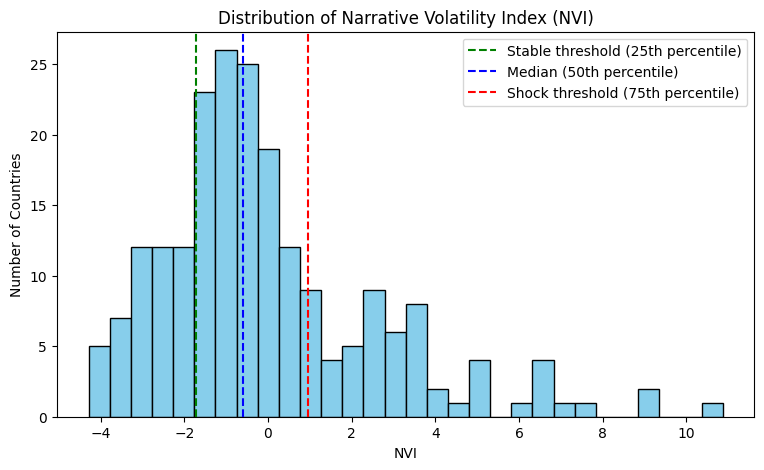

In [30]:
# Visualize NVI distribution
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# Compute quantile thresholds
q25 = df['NVI'].quantile(0.25)
q50 = df['NVI'].quantile(0.50)
q75 = df['NVI'].quantile(0.75)

print("NVI thresholds:")
print(f"25th percentile: {q25:.3f}")
print(f"50th percentile: {q50:.3f}")
print(f"75th percentile: {q75:.3f}")

# Visualize NVI distribution
plt.figure(figsize=(9, 5))
plt.hist(df['NVI'], bins=30, color='skyblue', edgecolor='black')

plt.axvline(q25, color='green', linestyle='--', label='Stable threshold (25th percentile)')
plt.axvline(q50, color='blue', linestyle='--', label='Median (50th percentile)')
plt.axvline(q75, color='red', linestyle='--', label='Shock threshold (75th percentile)')

plt.title("Distribution of Narrative Volatility Index (NVI)")
plt.xlabel("NVI")
plt.ylabel("Number of Countries")
plt.legend()
plt.show()

In [31]:
# Assign percentile-based regime labels
def nvi_label(nvi):
    if nvi < q25:
        return 'Stable'
    elif nvi > q75:
        return 'Shock'
    else:
        return 'Moderate'

df['nvi_label'] = df['NVI'].apply(nvi_label)

# Preview highest NVI countries
df[['country', 'NVI', 'nvi_label']].sort_values('NVI', ascending=False).head(10)

,country,NVI,nvi_label
0,SMR,10.865898,Shock
1,BDI,9.185717,Shock
2,GNB,9.053513,Shock
3,COM,7.523160,Shock
4,NRU,7.193067,Shock
5,GNQ,6.774593,Shock
6,EAF,6.631971,Shock
7,TMP,6.481909,Shock
8,AND,6.404837,Shock
9,MDG,6.065862,Shock


## 9.1 Robustness Check Using Standard Z-score Regimes

To evaluate whether the percentile-based regime labels are sensitive to the chosen thresholding method, a z-score based robustness check was also applied.

In this approach, the NVI values are standardized using their mean and standard deviation. Countries with z-scores below -1 are labeled as `Stable`, countries with z-scores above +1 are labeled as `Shock`, and the remaining countries are labeled as `Moderate`.

This provides an alternative thresholding strategy based on standard deviations rather than percentiles.

In [32]:
## 9.1 Robustness Check: Z-score Based Regimes

# Compute z-score of NVI
df['NVI_z'] = (df['NVI'] - df['NVI'].mean()) / df['NVI'].std()

# Assign z-score based regime labels
def nvi_z_label(z):
    if z < -1:
        return 'Stable'
    elif z > 1:
        return 'Shock'
    else:
        return 'Moderate'

df['nvi_z_label'] = df['NVI_z'].apply(nvi_z_label)

# Preview comparison
df[['country', 'NVI', 'NVI_z', 'nvi_label', 'nvi_z_label']] \
    .sort_values('NVI', ascending=False) \
    .head(10)

,country,NVI,NVI_z,nvi_label,nvi_z_label
0,SMR,10.865898,4.057640,Shock,Shock
1,BDI,9.185717,3.430211,Shock,Shock
2,GNB,9.053513,3.380843,Shock,Shock
3,COM,7.523160,2.809365,Shock,Shock
4,NRU,7.193067,2.686099,Shock,Shock
5,GNQ,6.774593,2.529828,Shock,Shock
6,EAF,6.631971,2.476569,Shock,Shock
7,TMP,6.481909,2.420532,Shock,Shock
8,AND,6.404837,2.391751,Shock,Shock
9,MDG,6.065862,2.265168,Shock,Shock


In [33]:
import pandas as pd

# Compare percentile-based and z-score based labels
label_comparison = pd.crosstab(
    df['nvi_label'],
    df['nvi_z_label'],
    rownames=['Percentile-based label'],
    colnames=['Z-score based label']
)

label_comparison

Z-score based label,Moderate,Shock,Stable
Percentile-based label,,,
Moderate,105,0,0
Shock,20,33,0
Stable,27,0,26


In [34]:
# Agreement rate between the two labeling approaches
agreement_rate = (df['nvi_label'] == df['nvi_z_label']).mean()

print(f"Agreement rate between percentile-based and z-score based labels: {agreement_rate:.2%}")

Agreement rate between percentile-based and z-score based labels: 77.73%


The agreement rate between percentile-based and z-score based labels is **77.73%**. This suggests that the regime classification is relatively robust to the choice of thresholding method. Most countries receive the same regime label under both approaches, while the differences are likely concentrated around countries located near the regime boundaries.

## 9.2 Robustness Check Using Robust Z-score Regimes

Since the NVI distribution is skewed, a robust z-score based on the median and Median Absolute Deviation (MAD) was used as an additional thresholding strategy.

Unlike the standard z-score, which depends on the mean and standard deviation, the robust z-score uses the median and MAD. Therefore, it is less sensitive to skewness and extreme values.

Countries with robust z-scores below -1 are labeled as `Stable`, countries with robust z-scores above +1 are labeled as `Shock`, and the remaining countries are labeled as `Moderate`.

This robustness check evaluates whether the main percentile-based regime labels remain stable under a more robust thresholding method.

In [80]:
## 9.2 Robustness Check: Robust Z-score Based Regimes

# Compute median and Median Absolute Deviation (MAD)
median_nvi = df['NVI'].median()
mad_nvi = (df['NVI'] - median_nvi).abs().median()

print(f"Median NVI: {median_nvi:.3f}")
print(f"MAD NVI: {mad_nvi:.3f}")

# Compute robust z-score
# 0.6745 makes the MAD-based score comparable to a standard z-score under normality
df['NVI_robust_z'] = 0.6745 * (df['NVI'] - median_nvi) / mad_nvi

# Assign robust z-score based regime labels
def robust_z_label(z):
    if z < -1:
        return 'Stable'
    elif z > 1:
        return 'Shock'
    else:
        return 'Moderate'

df['nvi_robust_label'] = df['NVI_robust_z'].apply(robust_z_label)

# Preview robust z-score based labels
df[['country', 'NVI', 'NVI_robust_z', 'nvi_label', 'nvi_robust_label']] \
    .sort_values('NVI', ascending=False) \
    .head(10)

Median NVI: -0.591
MAD NVI: 1.241


,country,NVI,NVI_robust_z,nvi_label,nvi_robust_label
0,SMR,10.865898,6.229179,Shock,Shock
1,BDI,9.185717,5.315680,Shock,Shock
2,GNB,9.053513,5.243802,Shock,Shock
3,COM,7.523160,4.411763,Shock,Shock
4,NRU,7.193067,4.232295,Shock,Shock
5,GNQ,6.774593,4.004775,Shock,Shock
6,EAF,6.631971,3.927232,Shock,Shock
7,TMP,6.481909,3.845645,Shock,Shock
8,AND,6.404837,3.803742,Shock,Shock
9,MDG,6.065862,3.619444,Shock,Shock


In [36]:
# Compare percentile-based and robust z-score based labels
robust_comparison = pd.crosstab(
    df['nvi_label'],
    df['nvi_robust_label'],
    rownames=['Percentile-based label'],
    colnames=['Robust z-score based label']
)

robust_comparison

Robust z-score based label,Moderate,Shock,Stable
Percentile-based label,,,
Moderate,105,0,0
Shock,3,50,0
Stable,19,0,34


In [37]:
# Agreement rate between percentile-based and robust z-score based labels
robust_agreement = (df['nvi_label'] == df['nvi_robust_label']).mean()

print(f"Agreement rate between percentile-based and robust z-score labels: {robust_agreement:.2%}")

Agreement rate between percentile-based and robust z-score labels: 89.57%


The agreement rate between percentile-based and robust z-score based labels is **89.57%**, which is higher than the agreement observed with the standard z-score approach. This suggests that the percentile-based classification is more consistent with a robust thresholding strategy based on the median and MAD. Since the NVI distribution is skewed, this result supports the use of percentile-based regimes as the main classification approach.

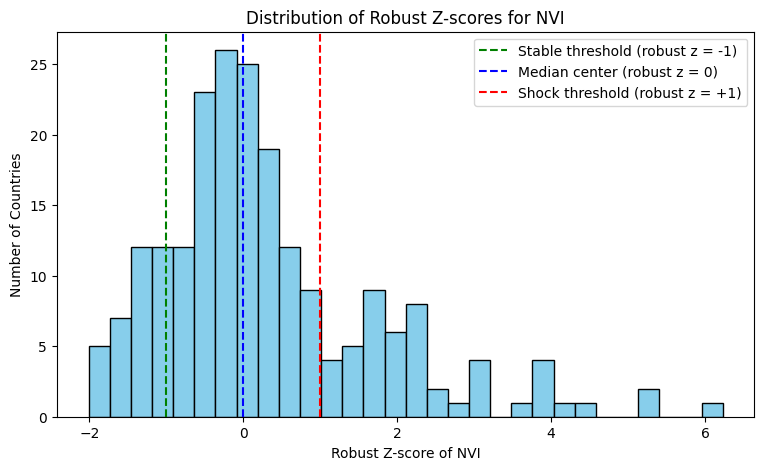

In [38]:
# Visualize robust z-score distribution
plt.figure(figsize=(9, 5))
plt.hist(df['NVI_robust_z'], bins=30, color='skyblue', edgecolor='black')

plt.axvline(-1, color='green', linestyle='--', label='Stable threshold (robust z = -1)')
plt.axvline(0, color='blue', linestyle='--', label='Median center (robust z = 0)')
plt.axvline(1, color='red', linestyle='--', label='Shock threshold (robust z = +1)')

plt.title("Distribution of Robust Z-scores for NVI")
plt.xlabel("Robust Z-score of NVI")
plt.ylabel("Number of Countries")
plt.legend()
plt.show()

## 10. Clustering as Exploratory Comparison

KMeans clustering is used only as an exploratory comparison, not as the main regime classification method.

The main NVI regime labels are rule-based and percentile-driven. KMeans, on the other hand, groups countries based on similarity in the selected feature space. Therefore, the two methods are not expected to produce identical results.

The purpose of this section is to examine whether the unsupervised cluster structure is broadly consistent with the NVI-based regime labels.

Silhouette Score: 0.4187234073540818


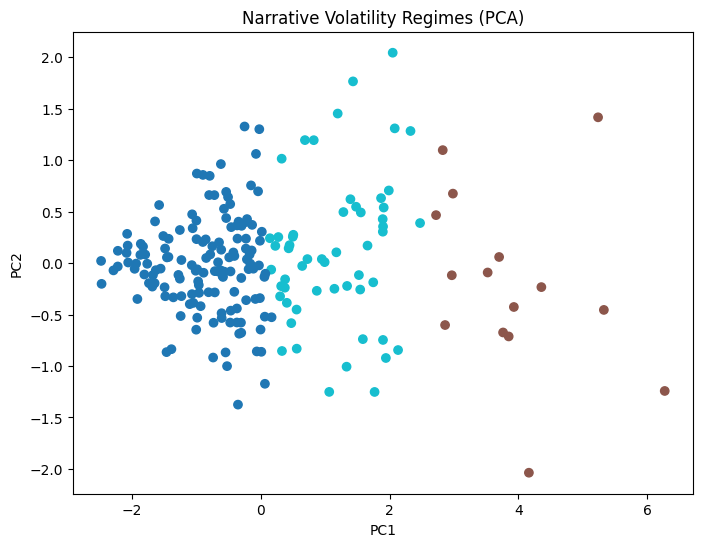

         tone_vol  goldstein_vol  entropy_vol  volatility_score
cluster                                                        
0        0.549138       0.366860     0.069446          0.985444
2        1.014802       0.664038     0.138941          1.817781
1        1.750553       1.127098     0.209699          3.087351
{0: 'Stable', 2: 'Moderate', 1: 'Shock'}


In [39]:
# Import required libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features for clustering (exclude NVI)
X = df[['tone_vol','goldstein_vol','entropy_vol']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Evaluate clustering
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, df['cluster'])
print("Silhouette Score:", score)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='tab10')
plt.title("Narrative Volatility Regimes (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Cluster summary
cluster_summary = df.groupby('cluster')[['tone_vol','goldstein_vol','entropy_vol']].mean()
cluster_summary['volatility_score'] = cluster_summary.sum(axis=1)
cluster_summary = cluster_summary.sort_values('volatility_score')

# Map clusters to regime labels
labels = ["Stable","Moderate","Shock"]
cluster_label_map = {cluster: label for cluster, label in zip(cluster_summary.index, labels)}
df['kmeans_label'] = df['cluster'].map(cluster_label_map)

# Display cluster summary and label mapping
print(cluster_summary)
print(cluster_label_map)

## 10.1 Global Map of Narrative Regimes (KMeans)

**Objective:** Visualize the clustering results on a world map.

**Steps:**

1. Load country shapefile.  
2. Merge with `kmeans_label` from clustering.  
3. Assign colors to each regime:  
   - `Shock` → red  
   - `Stable` → blue  
   - `Moderate` → gray  
4. Plot countries with regime colors. Missing countries are light gray.

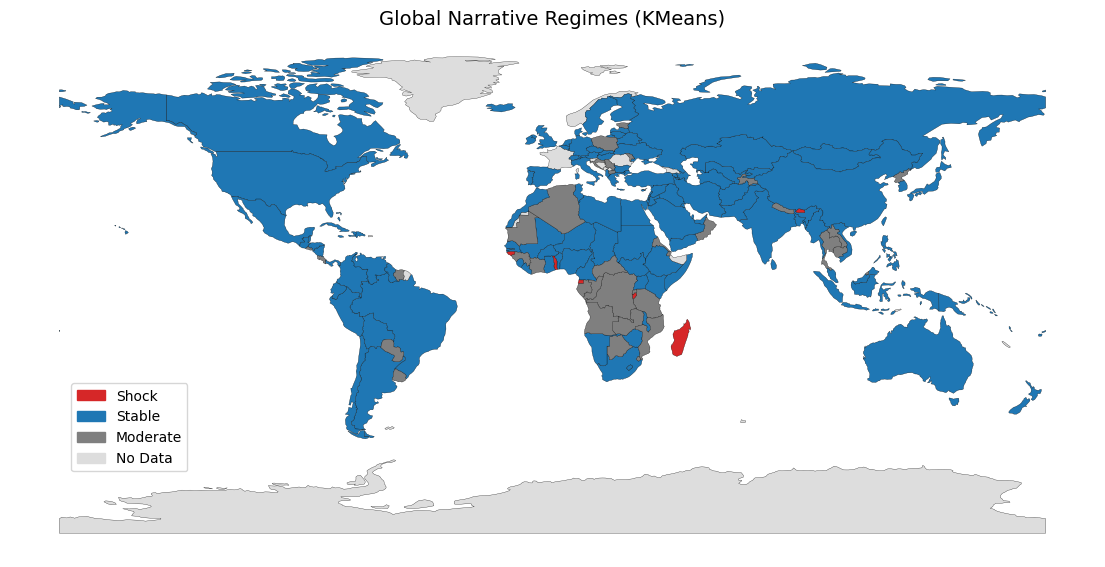

In [40]:
import geopandas as gpd
import zipfile
import tempfile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load country shapefile
zip_path = "../data/external/ne_110m_admin_0_countries.zip"
with zipfile.ZipFile(zip_path) as z:
    shp_file = [f for f in z.namelist() if f.endswith(".shp")][0]
    with tempfile.TemporaryDirectory() as tmpdir:
        z.extractall(tmpdir)
        world = gpd.read_file(f"{tmpdir}/{shp_file}")

# Rename ISO_A3 column for merging
world = world.rename(columns={"ISO_A3": "country"})

# Merge with clustering results
kmeans_map = world.merge(df[['country','kmeans_label']], on="country", how="left")

# Define color map
color_map_kmeans = {
    'Shock': "#d62728",
    'Stable': "#1f77b4",
    'Moderate': "#7f7f7f"
}

# Legend for KMeans
legend_patches = [
    mpatches.Patch(color="#d62728", label="Shock"),
    mpatches.Patch(color="#1f77b4", label="Stable"),
    mpatches.Patch(color="#7f7f7f", label="Moderate"),
    mpatches.Patch(color="#dddddd", label="No Data")
]

kmeans_map["color"] = kmeans_map["kmeans_label"].map(color_map_kmeans).fillna("#dddddd")

# Plot map
fig, ax = plt.subplots(figsize=(14,8))
kmeans_map.plot(color=kmeans_map["color"], edgecolor="black", linewidth=0.2, ax=ax)
ax.set_title("Global Narrative Regimes (KMeans)", fontsize=14)
ax.legend(handles=legend_patches, loc='lower left', frameon=True, bbox_to_anchor=(0.05, 0.15))
ax.axis("off")
plt.show()

## 10.2 Global Map of Narrative Volatility Index (NVI)

**Objective:** Compare clustering-based regimes with the continuous NVI measure.

**Steps:**

1. Assign discrete labels to countries based on NVI quantiles.  
2. Merge with world shapefile.  
3. Assign colors to NVI labels:
   - `Shock` → red  
   - `Stable` → blue  
   - `Low` → gray  
4. Plot countries with NVI regime colors. Missing countries are light gray.

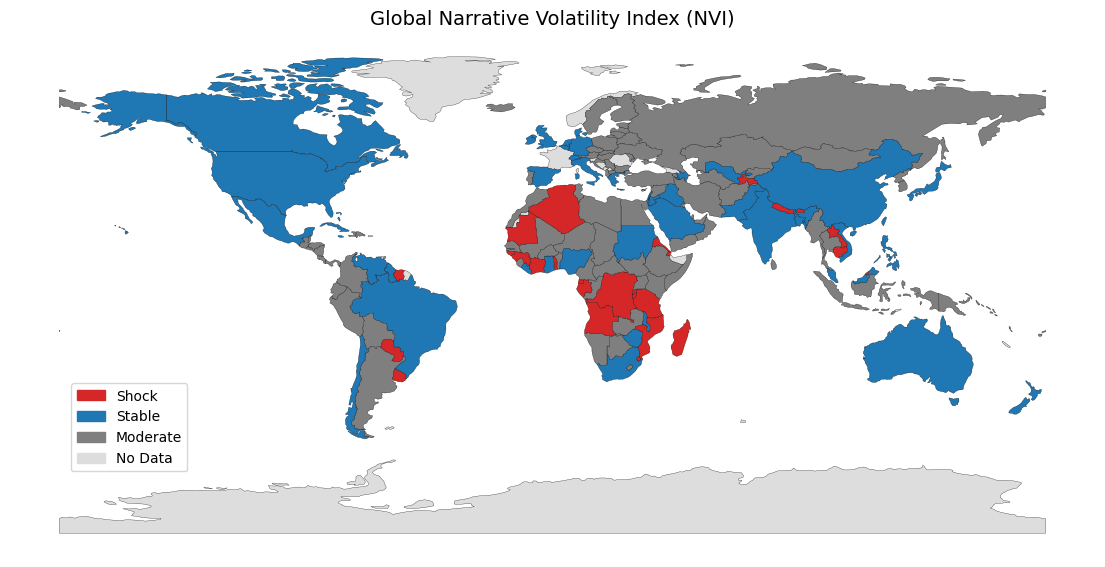

In [41]:
# Merge with world shapefile
nvi_map = world.merge(df[['country','nvi_label']], on="country", how="left")

color_map_nvi = {
    'Shock': "#d62728",
    'Stable': "#1f77b4",
    'Moderate': "#7f7f7f"
}
legend_patches = [
    mpatches.Patch(color="#d62728", label="Shock"),
    mpatches.Patch(color="#1f77b4", label="Stable"),
    mpatches.Patch(color="#7f7f7f", label="Moderate"),
    mpatches.Patch(color="#dddddd", label="No Data")
]

nvi_map["color"] = nvi_map["nvi_label"].map(color_map_nvi).fillna("#dddddd")

# Plot NVI map
fig, ax = plt.subplots(figsize=(14,8))
nvi_map.plot(color=nvi_map["color"], edgecolor="black", linewidth=0.2, ax=ax)
ax.legend(handles=legend_patches, loc='lower left', frameon=True, bbox_to_anchor=(0.05, 0.15))
ax.set_title("Global Narrative Volatility Index (NVI)", fontsize=14)
ax.axis("off")
plt.show()

### 10.3 Agreement Between KMeans and NVI Labels

In [42]:
# Compare KMeans labels with NVI labels
comparison_df = df[['country','NVI','kmeans_label','nvi_label']].copy()
comparison_df['same'] = comparison_df['kmeans_label'] == comparison_df['nvi_label']
agreement_rate = comparison_df['same'].mean()

print("Agreement rate between KMeans and NVI labels:", agreement_rate)

# Show countries where labels differ
diff_df = comparison_df[comparison_df['same'] == False].sort_values("NVI", ascending=False)
diff_df.head(20)

Agreement rate between KMeans and NVI labels: 0.4028436018957346


,country,NVI,kmeans_label,nvi_label,same
15,KIR,4.298482,Moderate,Shock,False
16,MAC,4.034192,Moderate,Shock,False
17,RWA,3.666648,Moderate,Shock,False
18,FSM,3.615023,Moderate,Shock,False
19,CRB,3.583444,Moderate,Shock,False
20,PGS,3.457839,Moderate,Shock,False
21,DJI,3.358652,Moderate,Shock,False
22,MHL,3.299954,Moderate,Shock,False
23,ABW,3.298870,Moderate,Shock,False
24,PLW,3.292066,Moderate,Shock,False


A low or moderate agreement between KMeans clusters and NVI labels does not invalidate the NVI. It indicates that the NVI captures an interpretable volatility score, while KMeans captures distance-based grouping patterns.

## 11. Method Comparison and Interpretation

This section compares the percentile-based NVI regime labels with the KMeans cluster labels. The comparison is used to understand whether the two approaches identify similar country groups.

However, because the two methods are based on different assumptions, the comparison should be interpreted as exploratory rather than as a formal validation test.

In [47]:
# Create comparison dataframe
comparison_df = df[['country','NVI','kmeans_label','nvi_label']].copy()
# Check where labels match
comparison_df['same'] = comparison_df['kmeans_label'] == comparison_df['nvi_label']
# Compute overall agreement rate
agreement_rate = comparison_df['same'].mean()
print("Agreement rate between KMeans and NVI labels:", agreement_rate)

Agreement rate between KMeans and NVI labels: 0.4028436018957346


In [48]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(comparison_df['kmeans_label'], comparison_df['nvi_label'])
print("Cohen's Kappa:", kappa)

Cohen's Kappa: 0.127698667891594


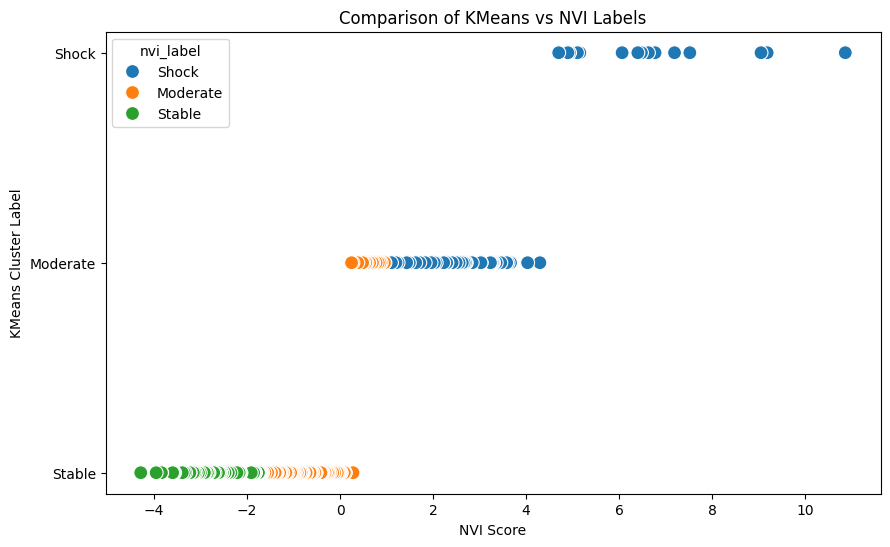

In [49]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=comparison_df, x='NVI', y='kmeans_label', hue='nvi_label', s=100)
plt.title("Comparison of KMeans vs NVI Labels")
plt.xlabel("NVI Score")
plt.ylabel("KMeans Cluster Label")
plt.show()

The agreement and Cohen's Kappa values suggest that KMeans and percentile-based NVI regimes do not fully overlap. This is expected because KMeans identifies geometric clusters, while the NVI regime labels are based on interpretable percentile thresholds of a composite volatility index.

## 12. Country-Level Case Analysis

After constructing the NVI and comparing regime classification methods, selected country-level patterns are examined more closely. This section focuses on high-NVI countries and selected cases to interpret how the NVI components contribute to narrative instability.

The purpose of this section is not to create a new model, but to provide an interpretable country-level reading of the NVI results.

### 12.1 Top Countries by NVI

The first country-level inspection focuses on the countries with the highest NVI values. These countries represent the strongest cases of narrative volatility in the sample.

A high NVI value does not necessarily mean that a country has the highest number of events. Instead, it indicates stronger instability in the volatility components used to construct the index.

In [52]:
top_nvi_countries = df[[
    "country",
    "NVI",
    "tone_vol",
    "goldstein_vol",
    "entropy_vol",
    "nvi_label"
]].sort_values("NVI", ascending=False).head(20)

top_nvi_countries

,country,NVI,tone_vol,goldstein_vol,entropy_vol,nvi_label
0,SMR,10.865898,1.497805,2.101037,0.280370,Shock
1,BDI,9.185717,2.360198,1.280219,0.231667,Shock
2,GNB,9.053513,2.157619,0.978124,0.312452,Shock
3,COM,7.523160,1.869374,1.203827,0.222034,Shock
4,NRU,7.193067,1.446784,1.710278,0.160945,Shock
5,GNQ,6.774593,1.950108,1.088163,0.192316,Shock
6,EAF,6.631971,1.966114,1.115850,0.176655,Shock
7,TMP,6.481909,1.940335,1.096643,0.175687,Shock
8,AND,6.404837,1.447401,1.166274,0.225451,Shock
9,MDG,6.065862,2.024639,0.875602,0.184985,Shock


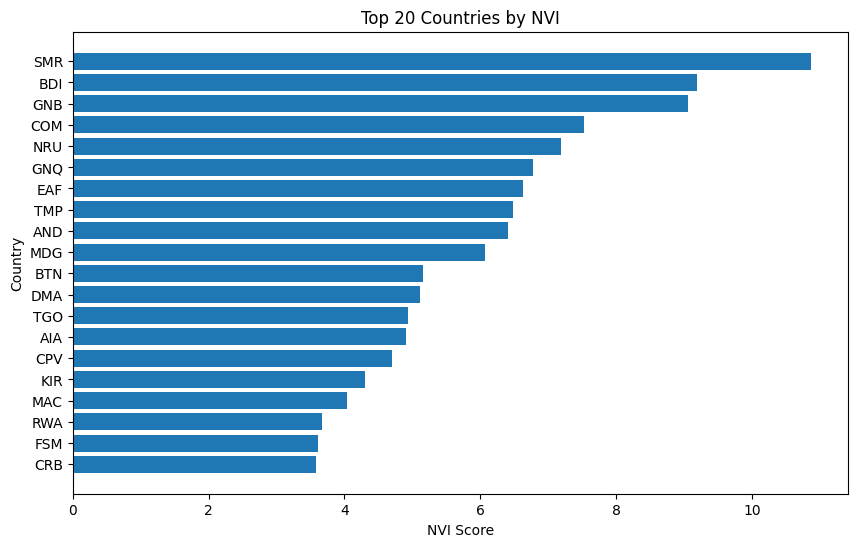

In [53]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_nvi_countries["country"],
    top_nvi_countries["NVI"]
)

plt.gca().invert_yaxis()
plt.title("Top 20 Countries by NVI")
plt.xlabel("NVI Score")
plt.ylabel("Country")
plt.show()

A notable pattern in the top NVI countries is the presence of several **small states, island countries, and low-coverage territories**. This suggests that high NVI values may partly reflect sensitivity to smaller event volumes.

In countries with fewer recorded events, relatively small changes in **tone**, **Goldstein score**, or **event-class composition** can produce larger volatility values.

Therefore, high NVI scores should **not** be interpreted directly as high geopolitical importance or high conflict intensity. Instead, they indicate **relative instability in the narrative indicators** used in the index.

The highest NVI value belongs to **SMR**, which is substantially higher than the rest of the top-ranked countries. This may indicate a strong volatility signal, but it may also reflect the sensitivity of rolling volatility measures in **low-coverage countries**.

For this reason, top-ranked countries should be interpreted together with **event volume indicators** and **country coverage**.

### 12.2 Most Stable Countries by NVI

This section examines the countries with the lowest NVI values. These countries represent the most stable cases in terms of the selected narrative volatility indicators.

A low NVI value does **not** necessarily mean that a country has no geopolitical events or no media attention. Instead, it indicates that the selected narrative indicators are relatively stable over the rolling time window.

In [75]:
stable_countries = df[[
    "country",
    "NVI",
    "tone_vol",
    "goldstein_vol",
    "entropy_vol",
    "nvi_label"
]].sort_values("NVI", ascending=True).head(20)

stable_countries

,country,NVI,tone_vol,goldstein_vol,entropy_vol,nvi_label
210,GBR,-4.285157,0.170044,0.096687,0.019926,Stable
209,USA,-4.274047,0.174826,0.140925,0.011066,Stable
208,AFR,-3.953803,0.210540,0.148120,0.022528,Stable
207,IRL,-3.839719,0.272183,0.129725,0.024047,Stable
206,CAN,-3.835104,0.247975,0.111116,0.031350,Stable
205,EUR,-3.599438,0.244667,0.153595,0.036450,Stable
204,CHN,-3.581260,0.211228,0.134782,0.045820,Stable
203,GHA,-3.575937,0.380547,0.079894,0.033724,Stable
202,DEU,-3.555690,0.222456,0.189430,0.034801,Stable
201,ZWE,-3.392498,0.437711,0.127332,0.026596,Stable


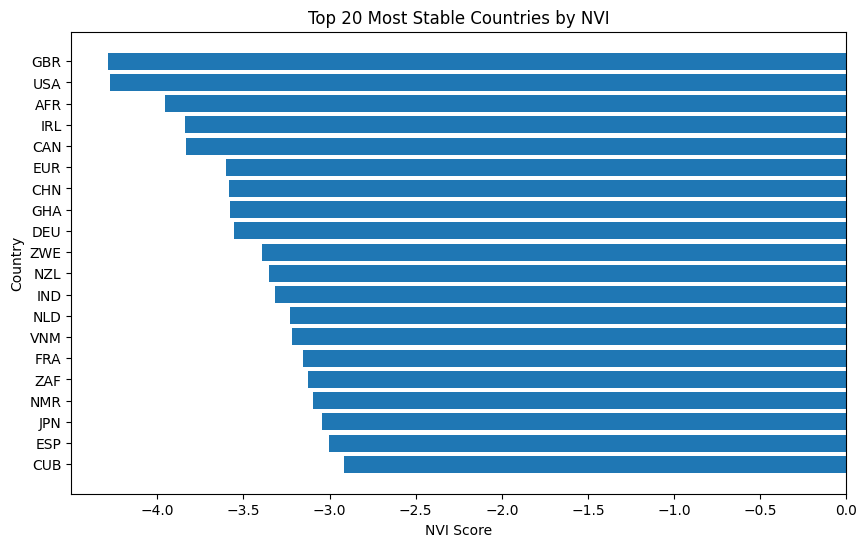

In [76]:
plt.figure(figsize=(10, 6))
plt.barh(
    stable_countries["country"],
    stable_countries["NVI"]
)

plt.gca().invert_yaxis()
plt.title("Top 20 Most Stable Countries by NVI")
plt.xlabel("NVI Score")
plt.ylabel("Country")
plt.show()

The lowest-ranked countries by NVI represent cases where tone volatility, Goldstein volatility, and entropy volatility are relatively low compared with the rest of the sample. These countries are classified as **Stable** because they fall below the 25th percentile of the NVI distribution.

However, stability in this context should be interpreted as **low narrative volatility**, not necessarily as political stability or absence of conflict. A country may still experience important events, but if the narrative indicators remain relatively consistent over time, its NVI can remain low.

In [77]:
stable_regime_countries = df[df["nvi_label"] == "Stable"][[
    "country",
    "NVI",
    "tone_vol",
    "goldstein_vol",
    "entropy_vol"
]].sort_values("NVI", ascending=True)

stable_regime_countries

,country,NVI,tone_vol,goldstein_vol,entropy_vol
210,GBR,-4.285157,0.170044,0.096687,0.019926
209,USA,-4.274047,0.174826,0.140925,0.011066
208,AFR,-3.953803,0.210540,0.148120,0.022528
207,IRL,-3.839719,0.272183,0.129725,0.024047
206,CAN,-3.835104,0.247975,0.111116,0.031350
205,EUR,-3.599438,0.244667,0.153595,0.036450
204,CHN,-3.581260,0.211228,0.134782,0.045820
203,GHA,-3.575937,0.380547,0.079894,0.033724
202,DEU,-3.555690,0.222456,0.189430,0.034801
201,ZWE,-3.392498,0.437711,0.127332,0.026596


### 12.3 Countries in the Shock Regime

This section focuses on countries classified as `Shock` according to the percentile-based NVI regime labels. These countries are located above the 75th percentile of the NVI distribution.

The Shock label should be interpreted as a relative narrative volatility category rather than a direct measure of conflict intensity.

In [54]:
shock_countries = df[df["nvi_label"] == "Shock"][[
    "country",
    "NVI",
    "tone_vol",
    "goldstein_vol",
    "entropy_vol"
]].sort_values("NVI", ascending=False)

shock_countries

,country,NVI,tone_vol,goldstein_vol,entropy_vol
0,SMR,10.865898,1.497805,2.101037,0.280370
1,BDI,9.185717,2.360198,1.280219,0.231667
2,GNB,9.053513,2.157619,0.978124,0.312452
3,COM,7.523160,1.869374,1.203827,0.222034
4,NRU,7.193067,1.446784,1.710278,0.160945
5,GNQ,6.774593,1.950108,1.088163,0.192316
6,EAF,6.631971,1.966114,1.115850,0.176655
7,TMP,6.481909,1.940335,1.096643,0.175687
8,AND,6.404837,1.447401,1.166274,0.225451
9,MDG,6.065862,2.024639,0.875602,0.184985


In [78]:
print(f"Number of countries in the Shock regime: {len(shock_countries)}")

Number of countries in the Shock regime: 53


The Shock regime contains **53 countries**, corresponding to the upper tail of the percentile-based NVI distribution. These countries are classified as Shock because their NVI values are above the 75th percentile.

This category should be interpreted as a **relative volatility regime**. It does not necessarily mean that all countries in this group experienced severe conflict or geopolitical crisis. Instead, it means that their narrative indicators fluctuated more strongly than most other countries in the sample.

### 12.4 Regime Counts

The distribution of countries across NVI regimes is summarized to show how many countries fall into the Stable, Moderate, and Shock categories.

In [56]:
regime_counts = df["nvi_label"].value_counts().reset_index()
regime_counts.columns = ["nvi_label", "country_count"]

regime_counts

,nvi_label,country_count
0,Moderate,105
1,Shock,53
2,Stable,53


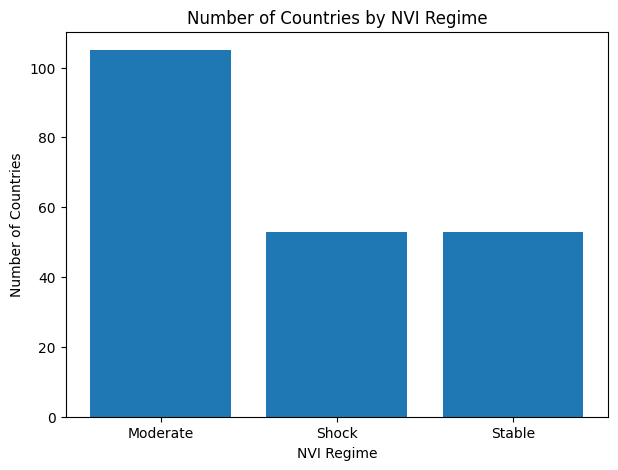

In [57]:
plt.figure(figsize=(7, 5))
plt.bar(regime_counts["nvi_label"], regime_counts["country_count"])

plt.title("Number of Countries by NVI Regime")
plt.xlabel("NVI Regime")
plt.ylabel("Number of Countries")
plt.show()

The regime count distribution is consistent with the percentile-based classification strategy. Since the lower 25% of countries are labeled as **Stable** and the upper 25% are labeled as **Shock**, both tail groups contain a similar number of countries. The remaining countries are classified as **Moderate**.

This confirms that the regime labels are based on the relative position of each country in the NVI distribution rather than on externally defined geopolitical thresholds.

### 12.5 Component-Level Interpretation

The NVI is composed of three volatility components: tone volatility, Goldstein volatility, and entropy volatility. To interpret the country-level results more clearly, the dominant component is identified for each country.

The dominant component is the component with the highest contribution among the three NVI components for that country.

In [58]:
component_cols = [
    "tone_vol",
    "goldstein_vol",
    "entropy_vol"
]

df["dominant_component"] = df[component_cols].idxmax(axis=1)

component_interpretation = df[[
    "country",
    "NVI",
    "nvi_label",
    "tone_vol",
    "goldstein_vol",
    "entropy_vol",
    "dominant_component"
]].sort_values("NVI", ascending=False)

component_interpretation.head(20)

,country,NVI,nvi_label,tone_vol,goldstein_vol,entropy_vol,dominant_component
0,SMR,10.865898,Shock,1.497805,2.101037,0.280370,goldstein_vol
1,BDI,9.185717,Shock,2.360198,1.280219,0.231667,tone_vol
2,GNB,9.053513,Shock,2.157619,0.978124,0.312452,tone_vol
3,COM,7.523160,Shock,1.869374,1.203827,0.222034,tone_vol
4,NRU,7.193067,Shock,1.446784,1.710278,0.160945,goldstein_vol
5,GNQ,6.774593,Shock,1.950108,1.088163,0.192316,tone_vol
6,EAF,6.631971,Shock,1.966114,1.115850,0.176655,tone_vol
7,TMP,6.481909,Shock,1.940335,1.096643,0.175687,tone_vol
8,AND,6.404837,Shock,1.447401,1.166274,0.225451,tone_vol
9,MDG,6.065862,Shock,2.024639,0.875602,0.184985,tone_vol


In [59]:
dominant_counts = df["dominant_component"].value_counts().reset_index()
dominant_counts.columns = ["dominant_component", "country_count"]

dominant_counts

,dominant_component,country_count
0,tone_vol,182
1,goldstein_vol,29


The dominant component analysis shows that **tone volatility is the dominant contributor for most countries**. Goldstein volatility is dominant in a smaller group of countries, while entropy volatility does not appear as the dominant component in the current country-level results.

This suggests that the NVI is mainly driven by fluctuations in **media tone**, rather than by changes in event-class diversity. However, entropy volatility still contributes to the final NVI score and helps capture structural changes in the distribution of event types.

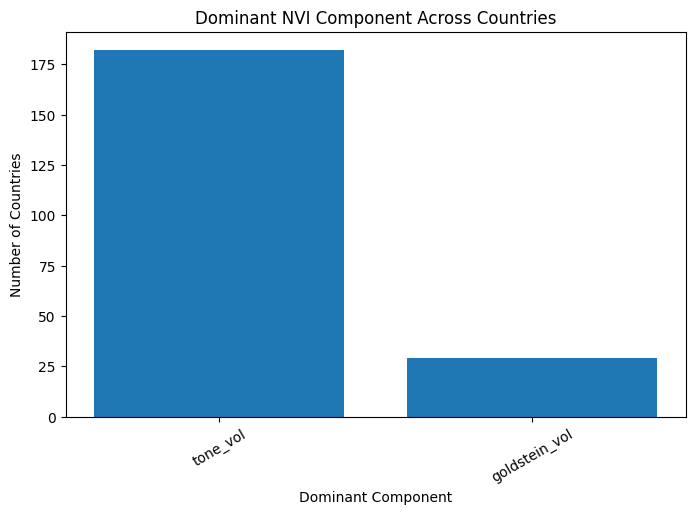

In [60]:
plt.figure(figsize=(8, 5))
plt.bar(dominant_counts["dominant_component"], dominant_counts["country_count"])

plt.title("Dominant NVI Component Across Countries")
plt.xlabel("Dominant Component")
plt.ylabel("Number of Countries")
plt.xticks(rotation=30)
plt.show()

The dominant component helps explain the source of narrative instability. For some countries, high NVI may be driven mainly by tone volatility, while for others it may be driven by Goldstein volatility or entropy volatility.

This decomposition makes the NVI easier to interpret because countries with similar NVI scores may still differ in terms of which component contributes most strongly to their narrative volatility.

### 12.6 Agreement of Regime Labels at Country Level

This section compares the percentile-based NVI labels with the two alternative robustness labels at the country level. The goal is to identify which countries receive consistent labels across methods and which countries are more sensitive to the thresholding strategy.

In [62]:
label_agreement_df = df[[
    "country",
    "NVI",
    "nvi_label",
    "nvi_z_label",
    "nvi_robust_label"
]].copy()

label_agreement_df["standard_z_agreement"] = (
    label_agreement_df["nvi_label"] == label_agreement_df["nvi_z_label"]
)

label_agreement_df["robust_z_agreement"] = (
    label_agreement_df["nvi_label"] == label_agreement_df["nvi_robust_label"]
)

label_agreement_df.sort_values("NVI", ascending=False).head(20)

,country,NVI,nvi_label,nvi_z_label,nvi_robust_label,standard_z_agreement,robust_z_agreement
0,SMR,10.865898,Shock,Shock,Shock,True,True
1,BDI,9.185717,Shock,Shock,Shock,True,True
2,GNB,9.053513,Shock,Shock,Shock,True,True
3,COM,7.523160,Shock,Shock,Shock,True,True
4,NRU,7.193067,Shock,Shock,Shock,True,True
5,GNQ,6.774593,Shock,Shock,Shock,True,True
6,EAF,6.631971,Shock,Shock,Shock,True,True
7,TMP,6.481909,Shock,Shock,Shock,True,True
8,AND,6.404837,Shock,Shock,Shock,True,True
9,MDG,6.065862,Shock,Shock,Shock,True,True


In [63]:
label_disagreements = label_agreement_df[
    (label_agreement_df["standard_z_agreement"] == False) |
    (label_agreement_df["robust_z_agreement"] == False)
].sort_values("NVI", ascending=False)

label_disagreements

,country,NVI,nvi_label,nvi_z_label,nvi_robust_label,standard_z_agreement,robust_z_agreement
33,TJK,2.668075,Shock,Moderate,Shock,False,True
34,SWZ,2.629633,Shock,Moderate,Shock,False,True
35,MRT,2.560442,Shock,Moderate,Shock,False,True
36,CAS,2.498462,Shock,Moderate,Shock,False,True
37,WAF,2.410021,Shock,Moderate,Shock,False,True
38,LAO,2.297687,Shock,Moderate,Shock,False,True
39,COD,2.293372,Shock,Moderate,Shock,False,True
40,URY,2.228779,Shock,Moderate,Shock,False,True
41,MUS,2.068478,Shock,Moderate,Shock,False,True
42,PRY,2.027955,Shock,Moderate,Shock,False,True


The disagreement table shows that many differences occur near the regime boundaries. For example, some countries labeled as `Shock` under the percentile-based method are classified as `Moderate` under the standard z-score method.

This supports the idea that **standard z-score thresholds are more sensitive to distributional shape**, while the percentile and robust z-score approaches are more consistent for skewed NVI distributions.

### 12.7 Selected Case Comparison

A selected case comparison is used to demonstrate how the NVI and its components can be interpreted at the country level. This comparison is descriptive and does not claim to explain the causes of geopolitical events.

In [64]:
df[df["country"].astype(str).str.contains("IR|IS|ISR|IRN", na=False)][[
    "country",
    "NVI",
    "nvi_label",
    "tone_vol",
    "goldstein_vol",
    "entropy_vol",
    "dominant_component"
]].sort_values("country")

,country,NVI,nvi_label,tone_vol,goldstein_vol,entropy_vol,dominant_component
207,IRL,-3.839719,Stable,0.272183,0.129725,0.024047,tone_vol
146,IRN,-1.395491,Moderate,0.405539,0.499924,0.067865,goldstein_vol
185,IRQ,-2.688478,Stable,0.396176,0.256226,0.045796,tone_vol
105,ISL,-0.591314,Moderate,0.641879,0.378256,0.104293,tone_vol
180,ISR,-2.531581,Stable,0.322818,0.477555,0.020513,goldstein_vol
15,KIR,4.298482,Shock,0.905110,1.022777,0.211595,goldstein_vol


In [67]:
case_countries = ["IRN", "ISR"]  

case_comparison = df[df["country"].isin(case_countries)][[
    "country",
    "NVI",
    "nvi_label",
    "tone_vol",
    "goldstein_vol",
    "entropy_vol",
    "dominant_component"
]]

case_comparison

,country,NVI,nvi_label,tone_vol,goldstein_vol,entropy_vol,dominant_component
146,IRN,-1.395491,Moderate,0.405539,0.499924,0.067865,goldstein_vol
180,ISR,-2.531581,Stable,0.322818,0.477555,0.020513,goldstein_vol


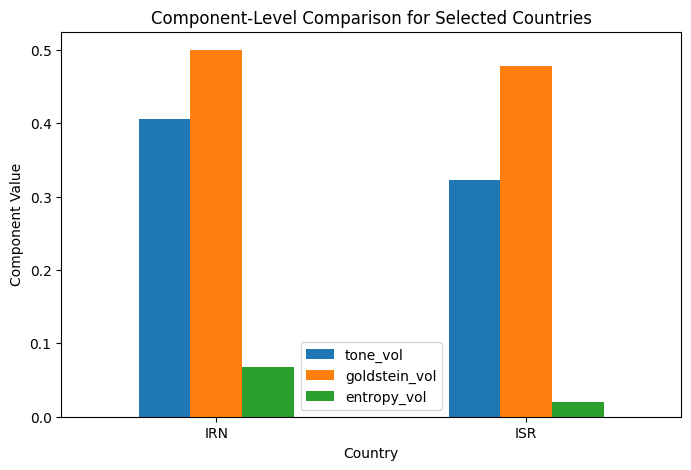

In [68]:
case_comparison.set_index("country")[[
    "tone_vol",
    "goldstein_vol",
    "entropy_vol"
]].plot(kind="bar", figsize=(8, 5))

plt.title("Component-Level Comparison for Selected Countries")
plt.xlabel("Country")
plt.ylabel("Component Value")
plt.xticks(rotation=0)
plt.show()

In this selected comparison, **IRN is classified as Moderate**, while **ISR is classified as Stable** according to the percentile-based NVI labels. Both countries have **Goldstein volatility** as their dominant component.

This result should be interpreted carefully. The NVI does not measure geopolitical importance or conflict intensity directly. Instead, it measures relative volatility in the selected narrative indicators. Therefore, politically salient countries do not necessarily appear in the Shock regime if their narrative indicators are relatively stable within the rolling window.

## 13. Regional Comparison of NVI Patterns

After the country-level interpretation, countries are grouped into selected regions to compare broader narrative volatility patterns. This section provides a regional reading of the NVI results.

The purpose of this analysis is descriptive. Regional averages should be interpreted carefully because some regions contain more countries than others, and some country codes may represent territories or regional aggregates rather than standard sovereign states.

In [70]:
region_map = {
    # Europe
    "ALB": "Europe", "AND": "Europe", "AUT": "Europe", "BEL": "Europe",
    "BGR": "Europe", "BIH": "Europe", "BLR": "Europe", "CHE": "Europe",
    "CYP": "Europe", "CZE": "Europe", "DEU": "Europe", "DNK": "Europe",
    "ESP": "Europe", "EST": "Europe", "FIN": "Europe", "FRA": "Europe",
    "GBR": "Europe", "GRC": "Europe", "HRV": "Europe", "HUN": "Europe",
    "IRL": "Europe", "ISL": "Europe", "ITA": "Europe", "LIE": "Europe",
    "LTU": "Europe", "LUX": "Europe", "LVA": "Europe", "MDA": "Europe",
    "MKD": "Europe", "MLT": "Europe", "MNE": "Europe", "NLD": "Europe",
    "NOR": "Europe", "POL": "Europe", "PRT": "Europe", "ROU": "Europe",
    "RUS": "Europe/Asia", "SMR": "Europe", "SRB": "Europe", "SVK": "Europe",
    "SVN": "Europe", "SWE": "Europe", "UKR": "Europe",

    # Asia
    "AFG": "Asia", "ARM": "Asia", "AZE": "Asia", "BGD": "Asia",
    "BTN": "Asia", "CHN": "Asia", "GEO": "Asia", "IDN": "Asia",
    "IND": "Asia", "JPN": "Asia", "KAZ": "Asia", "KGZ": "Asia",
    "KHM": "Asia", "KOR": "Asia", "LAO": "Asia", "LKA": "Asia",
    "MMR": "Asia", "MNG": "Asia", "MYS": "Asia", "NPL": "Asia",
    "PAK": "Asia", "PHL": "Asia", "PRK": "Asia", "SGP": "Asia",
    "THA": "Asia", "TJK": "Asia", "TKM": "Asia", "UZB": "Asia",
    "VNM": "Asia",

    # Africa
    "AGO": "Africa", "BDI": "Africa", "BEN": "Africa", "BFA": "Africa",
    "BWA": "Africa", "CAF": "Africa", "CIV": "Africa", "CMR": "Africa",
    "COD": "Africa", "COG": "Africa", "COM": "Africa", "CPV": "Africa",
    "DJI": "Africa", "DZA": "Africa", "EGY": "Africa", "ERI": "Africa",
    "ETH": "Africa", "GAB": "Africa", "GHA": "Africa", "GIN": "Africa",
    "GMB": "Africa", "GNB": "Africa", "GNQ": "Africa", "KEN": "Africa",
    "LBR": "Africa", "LBY": "Africa", "LSO": "Africa", "MAR": "Africa",
    "MDG": "Africa", "MLI": "Africa", "MOZ": "Africa", "MRT": "Africa",
    "MUS": "Africa", "MWI": "Africa", "NAM": "Africa", "NER": "Africa",
    "NGA": "Africa", "RWA": "Africa", "SDN": "Africa", "SEN": "Africa",
    "SLE": "Africa", "SOM": "Africa", "SSD": "Africa", "STP": "Africa",
    "SWZ": "Africa", "SYC": "Africa", "TCD": "Africa", "TGO": "Africa",
    "TUN": "Africa", "TZA": "Africa", "UGA": "Africa", "ZAF": "Africa",
    "ZMB": "Africa", "ZWE": "Africa",

    # Gulf
    "BHR": "Gulf", "KWT": "Gulf", "OMN": "Gulf",
    "QAT": "Gulf", "SAU": "Gulf", "ARE": "Gulf",

    # Broader Middle East
    "IRN": "Middle East", "IRQ": "Middle East", "ISR": "Middle East",
    "JOR": "Middle East", "LBN": "Middle East", "SYR": "Middle East",
    "TUR": "Middle East", "YEM": "Middle East", "PSE": "Middle East",

    # Americas
    "ARG": "Americas", "ATG": "Americas", "BHS": "Americas", "BLZ": "Americas",
    "BOL": "Americas", "BRA": "Americas", "BRB": "Americas", "CAN": "Americas",
    "CHL": "Americas", "COL": "Americas", "CRI": "Americas", "CUB": "Americas",
    "DMA": "Americas", "DOM": "Americas", "ECU": "Americas", "GRD": "Americas",
    "GTM": "Americas", "GUY": "Americas", "HND": "Americas", "HTI": "Americas",
    "JAM": "Americas", "MEX": "Americas", "NIC": "Americas", "PAN": "Americas",
    "PER": "Americas", "PRY": "Americas", "SLV": "Americas", "SUR": "Americas",
    "TTO": "Americas", "URY": "Americas", "USA": "Americas", "VEN": "Americas",

    # Oceania / Pacific
    "AUS": "Oceania", "FJI": "Oceania", "FSM": "Oceania", "KIR": "Oceania",
    "MHL": "Oceania", "NRU": "Oceania", "NZL": "Oceania", "PLW": "Oceania",
    "PNG": "Oceania", "SLB": "Oceania", "TON": "Oceania", "TUV": "Oceania",
    "VUT": "Oceania", "WSM": "Oceania"
}

df["region"] = df["country"].map(region_map).fillna("Other / Unmapped")

### 13.1 Regional Summary Statistics

The regional summary compares average NVI values and the number of countries in each region. This provides a broader view of how narrative volatility differs across regional groups.

In [71]:
regional_summary = df.groupby("region").agg(
    country_count=("country", "count"),
    mean_NVI=("NVI", "mean"),
    median_NVI=("NVI", "median"),
    max_NVI=("NVI", "max"),
    shock_count=("nvi_label", lambda x: (x == "Shock").sum()),
    stable_count=("nvi_label", lambda x: (x == "Stable").sum())
).reset_index()

regional_summary["shock_share"] = regional_summary["shock_count"] / regional_summary["country_count"]

regional_summary.sort_values("mean_NVI", ascending=False)

,region,country_count,mean_NVI,median_NVI,max_NVI,shock_count,stable_count,shock_share
0,Africa,53,0.964181,-0.031354,9.185717,21,7,0.396226
7,Oceania,14,0.953648,0.334063,7.193067,6,2,0.428571
8,Other / Unmapped,30,0.783921,-0.037320,6.631971,13,4,0.433333
5,Gulf,6,-0.497163,-0.375931,0.723203,0,1,0.000000
1,Americas,32,-0.694027,-0.629039,5.106020,5,11,0.156250
3,Europe,38,-0.698003,-1.056650,10.865898,3,12,0.078947
2,Asia,28,-0.716088,-1.315202,5.156658,5,11,0.178571
4,Europe/Asia,1,-1.614719,-1.614719,-1.614719,0,0,0.000000
6,Middle East,9,-1.621017,-1.754275,-0.006359,0,5,0.000000


The regional summary shows that **Africa** and **Oceania** have the highest average NVI values among the mapped regions. These regions also contain relatively high shares of countries in the **Shock** regime.

However, this result should be interpreted carefully. Both regions include several small states, island countries, and countries with potentially uneven event coverage. Therefore, higher regional NVI values may partly reflect **coverage sensitivity** rather than only substantive geopolitical instability.

The **Middle East** and **Gulf** groups show lower average NVI values and no countries in the Shock regime in this sample. This does not imply that these regions are geopolitically unimportant or conflict-free. Rather, it suggests that the selected narrative indicators were relatively less volatile according to the NVI framework and the rolling time window used in this project.

### 13.2 Regional NVI Comparison Plot

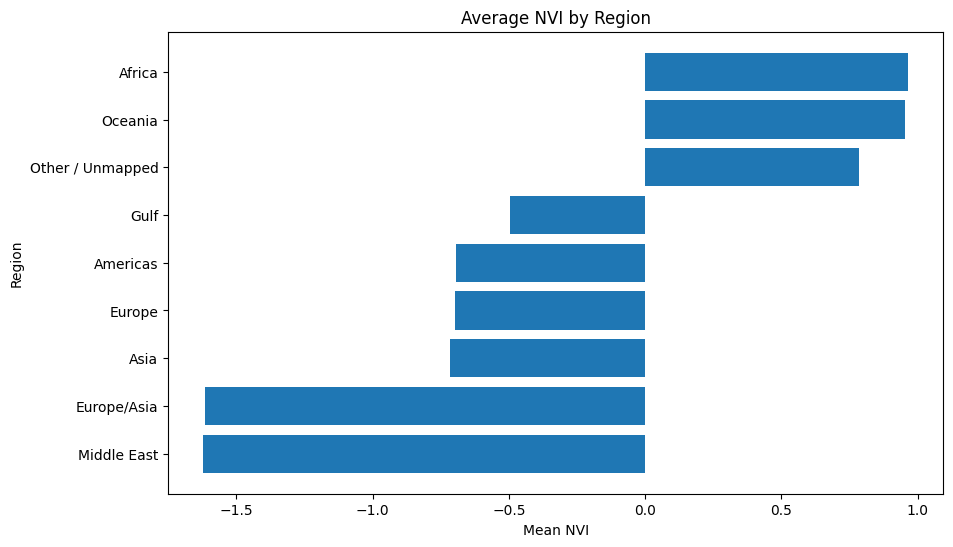

In [73]:
regional_plot = regional_summary.sort_values("mean_NVI", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(regional_plot["region"], regional_plot["mean_NVI"])

plt.title("Average NVI by Region")
plt.xlabel("Mean NVI")
plt.ylabel("Region")
plt.show()

The regional NVI comparison indicates that average narrative volatility differs across regions. Regions with higher mean NVI values are characterized by stronger average instability in the selected narrative indicators.

At the same time, regional means can be affected by outlier countries. For example, a single very high-NVI country can increase the regional average, especially in regions with fewer countries. Therefore, both **mean NVI** and **shock share** should be interpreted together.

### 13.3 Shock Share by Region

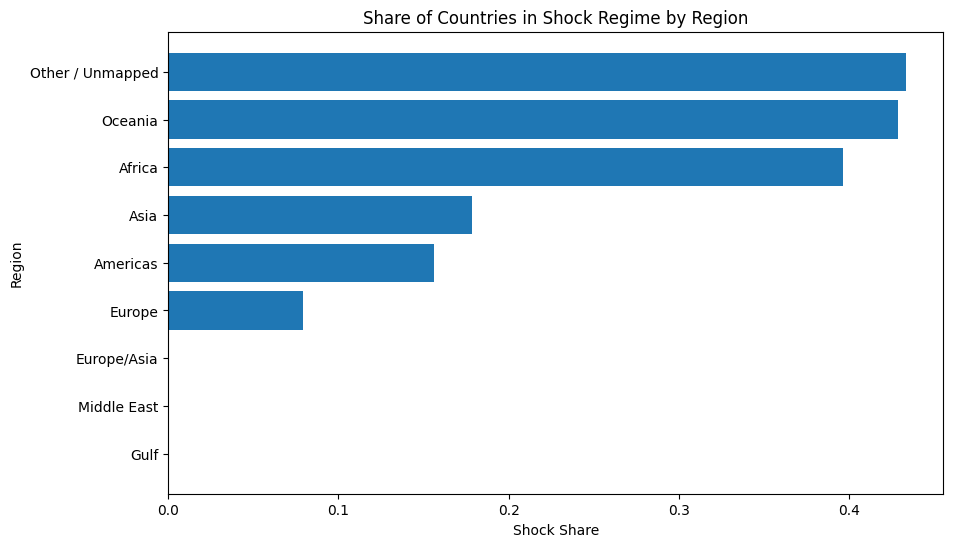

In [74]:
shock_share_plot = regional_summary.sort_values("shock_share", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(shock_share_plot["region"], shock_share_plot["shock_share"])

plt.title("Share of Countries in Shock Regime by Region")
plt.xlabel("Shock Share")
plt.ylabel("Region")
plt.show()

The shock-share comparison complements the regional mean NVI analysis by showing the proportion of countries classified as **Shock** within each region.

The results suggest that **Oceania**, **Africa**, and the **Other / Unmapped** group contain the highest proportions of Shock-regime countries. This pattern is consistent with the earlier country-level finding that many high-NVI countries are small states, island countries, or lower-coverage territories.

Therefore, regional shock shares should be interpreted as descriptive indicators of **relative narrative volatility**, not as direct measures of regional conflict intensity.

## 14. Discussion, Limitations, and Future Improvements

The NVI provides an interpretable way to measure **narrative volatility** using GDELT event data. By combining tone volatility, Goldstein volatility, and entropy volatility, the index captures different dimensions of instability in country-level geopolitical narratives.

However, several limitations should be considered when interpreting the results.

First, high NVI values do **not** directly indicate high conflict intensity, geopolitical importance, or political instability. The index measures volatility in selected narrative indicators, not the absolute severity of events.

Second, the country-level results show that several small states, island countries, and low-coverage territories appear among the highest-NVI cases. This suggests that the index may be sensitive to **event coverage sparsity**. In countries with fewer recorded events, relatively small changes in the underlying indicators can produce larger volatility values.

Third, the NVI uses an equal-weighted composite structure. This makes the index easier to interpret, but it assumes that tone volatility, Goldstein volatility, and entropy volatility contribute equally to narrative instability. Future work could compare this approach with **PCA-based weighting** or other data-driven weighting schemes.

Fourth, the regional analysis is based on manually assigned region groups. Some country codes may refer to territories, regional aggregates, or non-standard geographic units. Therefore, regional results should be interpreted as descriptive rather than definitive.

Future improvements could include:

- applying a **minimum event-count threshold** before ranking countries,
- adding **event-volume weighting** to reduce low-coverage sensitivity,
- comparing equal-weighted NVI with a **PCA-weighted NVI**,
- using full country names instead of only country codes,
- extending the analysis to a longer time period,
- validating the NVI against external geopolitical risk or conflict indicators.

## 15. Summary

This notebook constructed and analyzed the **Narrative Volatility Index (NVI)** using cleaned GDELT event data. The event-level data was first aggregated to the country-month level using action geography as the country identifier. Structural entropy was computed from QuadClass event distributions to capture variation in broad event types.

Rolling volatility measures were calculated for **average tone**, **Goldstein score**, and **QuadClass entropy**. These volatility components were then combined into an equal-weighted composite index. Higher NVI values indicate stronger instability in the selected narrative indicators.

Countries were classified into **Stable**, **Moderate**, and **Shock** regimes using percentile-based thresholds. Standard z-score and robust median-MAD z-score classifications were used as robustness checks. The robust z-score method showed stronger agreement with the percentile-based labels, supporting the use of percentile-based regimes for the skewed NVI distribution.

The country-level analysis showed that many high-NVI cases are small states, island countries, or lower-coverage territories. This suggests that NVI rankings should be interpreted together with **event coverage** and **component-level information**.

The regional comparison showed that Africa and Oceania had relatively higher average NVI values and higher shock shares in this sample, while the Middle East and Gulf groups showed lower average NVI values. These results should be interpreted descriptively and should not be treated as direct measures of conflict severity.

Overall, the NVI should be understood as a measure of **narrative volatility**, not as a direct measure of geopolitical risk, political stability, or conflict intensity.